- 2022.09.03    u.k., k.i. 
- 2022.09.10    k.i., t.k.   include plasma measurement 
- 2023.04.01    k.i., u.k.   ion temperature and fixed ionization ratio 
- 2023.04.17    u.k.         statistical non equilibrium with kawate-san's method (correction factor)

# He plasma statistical non equilibrium @ICP-Kawate

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

import os

In [2]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util import HelpUtil
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib
#from spectra.Function.SEquil import SELib
from spectra.Function.Icp import SELib

from spectra.Atomic import Hydrogen
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel

---

In [3]:
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He_I_II.conf" )
atom12, wMesh12, path_dict12 = Atom.init_Atom_(conf_path , is_hydrogen=False)
#HelpUtil.help_( atom12 )

In [4]:
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He_I.conf" )
atom1, wMesh1, path_dict1 = Atom.init_Atom_(conf_path , is_hydrogen=False)
#HelpUtil.help_( atom1 )

---

In [5]:
atom   = atom12
wMesh  = wMesh12

## step 2. calculate the transition rate matrix

Te = 5E4
Ti = 1E3
Pg_pa = 5  # [Pa]
Pg = Pg_pa * 10 # [dyne/cm^2, cgs]
Vd = 0.
Vt = 0.            #   cm/s

stage_pop = np.array([1.0,1E-8])  # set to 0 will cause NAN value in solving equation Ax=b
stage_pop[:] /= stage_pop.sum()
#stage_pop = None

slab = Atmosphere.Atmosphere0D(Nh=0.0, Ne=0.0, Te=Te, Vd=Vd, Vt=Vt, Pg=Pg, Ti=Ti)
radiation = Radiation.init_Radiation_(slab, wMesh)
radiation.backRad[1,:] = 0.0       # no incident intensity for b-b transition
radiation.PI_intensity[:,:] = 0    #  no incident intensity for b-f transition


SEcon, Ratecon = SELib.cal_SE_with_Pg_Te_single_Atom_(atom, slab, wMesh, radiation, stage_pop, rate_only=True)
SEcon12, Ratecon12 = SEcon, Ratecon
f"{slab.Nh:.2E}", f"{slab.Ne:.2E}"

('3.62E+14', '3.62E+06')

---

In [6]:
atom   = atom1
wMesh  = wMesh1


## step 2. calculate the transition rate matrix

# Te = 5E4
# Ti = 3E2
# Pg_pa = 5  # [Pa]
# Pg = Pg_pa * 10 # [Ba, cgs]
# Vd = 0.
# Vt = 0.            #   cm/s
# Ne = 1E10  # [/cm^{3}]

#stage_pop = np.array([1.0,1E-5])  # set to 0 will cause NAN value in solving equation Ax=b
#stage_pop[:] /= stage_pop.sum()
#stage_pop = None

slab.Nh = 0.0
#slab = Atmosphere.Atmosphere0D(Nh=0.0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, Pg=Pg, Ti=Ti)
radiation = Radiation.init_Radiation_(slab, wMesh)
radiation.backRad[1,:] = 0.0     # no incident intensity for b-b transition
radiation.PI_intensity[:,:] = 0    #  no incident intensity for b-f transition


SEcon, Ratecon = SELib.cal_SE_with_Pg_Te_Ne_single_Atom_(atom, slab, wMesh, radiation, None, rate_only=False)
SEcon1, Ratecon1 = SEcon, Ratecon

f"{slab.Nh:.2E}", f"{slab.Ne:.2E}"

('3.62E+14', '3.62E+06')

In [97]:
nLine = atom12.nLine
nCont = atom12.nCont
nLevel= atom12.nLevel -1
Ratecon = Ratecon12

## customize population for calculating correction factor
SEcon12.n_SE[-1] = stage_pop[-1]
SEcon12.n_SE[:-1] = stage_pop[0] * SEcon1.n_SE[:]

facs = np.zeros(nLevel)
n_SE = SEcon12.n_SE.copy()

print("recombi, ionize , exciout, exciin , factor")
print("-"*40)
for i in range(nLevel):
    ## recombination
    recom = 0.0
    for j in range(nCont):
        if i==atom12.Cont["idxI"][j]: 
            kk = atom12.Cont["idxJ"][j]
            recom += Ratecon.Rji_spon[nLine+j] * n_SE[kk]
            recom += Ratecon.Rji_stim[nLine+j] * n_SE[kk]
            recom += Ratecon.Cji_Ne[nLine+j] * n_SE[kk]
    ## ionization
    ioniz = 0.0
    for j in range(nCont):
        if i==atom12.Cont["idxI"][j]:
            kk = i
            ioniz += Ratecon.Rij[nLine+j] * n_SE[kk]
            ioniz += Ratecon.Cij_Ne[nLine+j] * n_SE[kk]
    ## (de)excitation outward and inward
    exci_out = 0.0
    exci_in  = 0.0
    for j in range(nLine):
        ## deexcitation
        if i==atom12.Line["idxJ"][j]:
            kk = i
            exci_out += Ratecon.Rji_spon[j] * n_SE[kk]
            exci_out += Ratecon.Rji_stim[j] * n_SE[kk]
            exci_out += Ratecon.Cji_Ne[j] * n_SE[kk]
            kk = atom12.Line["idxI"][j]
            exci_in  += Ratecon.Rij[j] * n_SE[kk]
            exci_in  += Ratecon.Cij_Ne[j] * n_SE[kk]
        ## excitation
        if i==atom12.Line["idxI"][j]:
            kk = i
            exci_out += Ratecon.Rij[j] * n_SE[kk]
            exci_out += Ratecon.Cij_Ne[j] * n_SE[kk]
            kk = atom12.Line["idxJ"][j]
            exci_in += Ratecon.Rji_spon[j] * n_SE[kk]
            exci_in += Ratecon.Rji_stim[j] * n_SE[kk]
            exci_in += Ratecon.Cji_Ne[j] * n_SE[kk]
    facs[i] = (recom - ioniz) / (exci_in)# - exci_out)
    print(f"{recom:.1E}, {ioniz:.1E}, {exci_out:.1E}, {exci_in:.1E}, {facs[i]:+.1E}")


recombi, ionize , exciout, exciin , factor
----------------------------------------
2.6E-15, 1.1E-04, 1.9E-03, 1.9E-03, -5.7E-02
3.1E-16, 7.0E-05, 2.6E-02, 2.6E-02, -2.7E-03
9.8E-17, 1.4E-05, 3.5E-03, 3.5E-03, -3.9E-03
3.6E-16, 2.8E-10, 3.1E-01, 3.1E-01, -9.1E-10
2.2E-16, 1.7E-10, 3.0E-01, 3.0E-01, -5.6E-10
7.3E-17, 6.5E-11, 1.0E-02, 1.0E-02, -6.4E-09
1.3E-16, 1.9E-13, 3.5E-03, 3.5E-03, -5.3E-11
7.1E-17, 4.0E-12, 3.8E-04, 3.8E-04, -1.1E-08
2.6E-17, 8.8E-12, 2.3E-04, 2.3E-04, -3.8E-08
2.3E-16, 2.6E-11, 4.0E-04, 4.0E-04, -6.5E-08
5.1E-17, 1.6E-12, 8.6E-02, 8.6E-02, -1.9E-11
3.7E-17, 1.1E-12, 8.6E-02, 8.6E-02, -1.3E-11
2.2E-17, 7.1E-13, 1.6E-03, 1.6E-03, -4.4E-10
3.6E-17, 3.1E-12, 2.2E-04, 2.2E-04, -1.4E-08
5.1E-17, 2.3E-13, 4.0E-04, 4.0E-04, -5.8E-10
2.3E-17, 3.0E-12, 1.1E-04, 1.1E-04, -2.8E-08
9.5E-18, 7.5E-12, 8.1E-05, 8.1E-05, -9.3E-08
3.3E-17, 1.7E-14, 8.9E-05, 8.9E-05, -1.9E-10
7.5E-17, 3.3E-12, 8.2E-05, 8.2E-05, -4.0E-08
2.4E-17, 5.2E-12, 7.9E-05, 7.9E-05, -6.6E-08


In [98]:
SEcon1.n_SE[:] *= (1.+facs[:])
SEcon1.n_SE /= SEcon1.n_SE.sum()
print(SEcon1.n_SE)

## line intensity
depth = 10. # cm   6.E3 * 1.E5 #   km *1e5
lHe = CloudModel.SE_to_slab_0D_(atom1, slab, SEcon1, depth=depth)

[9.98025360e-01 1.83151919e-03 1.43117676e-04 1.44060299e-09
 8.67050739e-10 3.40760093e-10 1.01149711e-12 1.43504018e-11
 1.40633277e-11 2.02336686e-11 1.81830631e-12 1.29975259e-12
 8.13788982e-13 3.61758880e-12 1.81097199e-13 3.53091921e-12
 3.89767336e-12 3.28902864e-12 9.13498549e-13 1.47044876e-12]


D:\home\Python\spectra\spectra\Function\SlabModel\CloudModel.py:47: RuntimeWarning: invalid value encountered in true_divide
  Src   : T_ARRAY = ( Aji * nj ) / ( Bij * ni - Bji * nj )


dict_keys(['wl', 'pr', 'sp50w'])


array([0.4, 0.5, 1. , 2. , 3. , 4. , 5.3], dtype=float32)

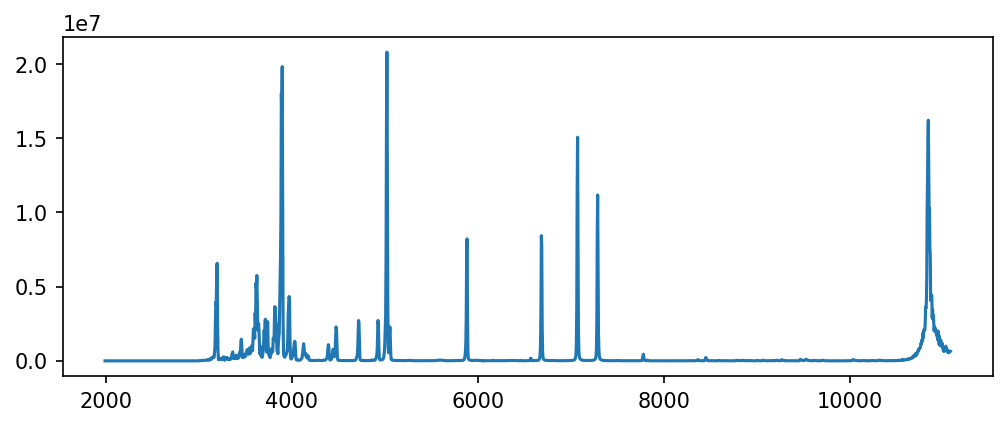

In [99]:
import scipy.io as sio

filename = 'D:\data\hida\plasma/sp50w_pscan.sav'   # data on 2022.09.02
d = sio.readsav(filename)
#print(d.date_obs)
print(d.keys())

wlo = d.wl[0:2048] *10    # nm
spo = d.sp50w[2,:]  # W/m^2/nm
# W/m^2/nm  -> erg/cm^3/s/str
spo = spo * 1E7 * 1E-4 * 1E7

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(wlo,spo,label='He')

d.pr

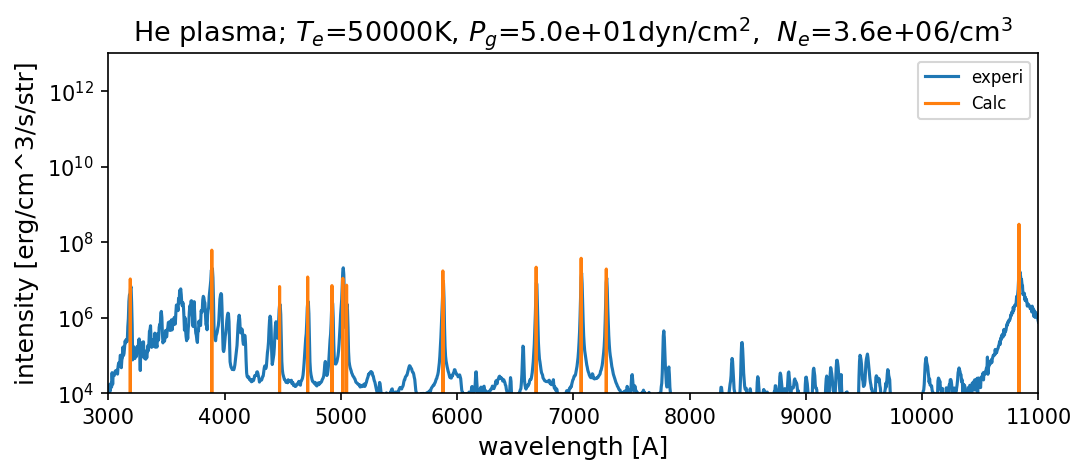

In [100]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)

ax.plot(wlo,spo,label='experi')
ax.plot(lHe.wl_1D*1e8,lHe.prof_1D,'-',label='Calc')

#ax.set_ylim(1e9,1E14)
#ax.set_xlim(500, 50000)
#ax.set_xscale("log")
ax.set_xlim(3000, 11000)
ax.set_yscale("log")
ax.set_ylim(1e4, 1e13)
#ax.set_ylim(0, 6e7)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("He plasma; $T_e$={0:5.0f}K, $P_g$={1:5.1e}dyn/cm$^{{2}}$,  $N_e$={2:5.1e}/cm$^{{3}}$".format(Te, Pg, slab.Ne),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

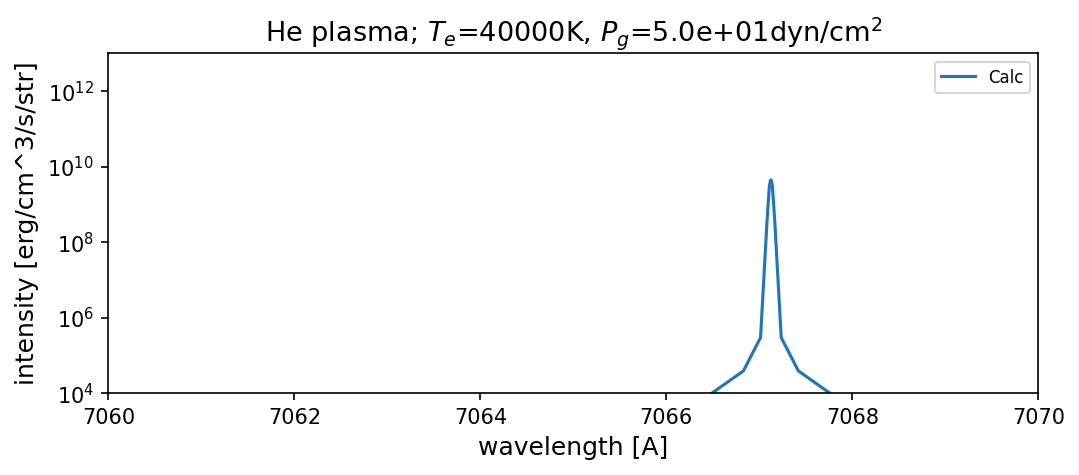

In [50]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)

ax.plot(lHe.wl_1D*1e8,lHe.prof_1D,'-',label='Calc')

ax.set_xlim(3000, 11000)
ax.set_yscale("log")
ax.set_ylim(1e4, 1e13)
ax.set_xlim(7060, 7070)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("He plasma; $T_e$={0:5.0f}K, $P_g$={1:5.1e}dyn/cm$^{{2}}$".format(Te, Pg),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

---

In [7]:
atom   = atom1
wMesh  = wMesh1


## step 2. calculate the transition rate matrix

Te = 5E4
Ti = 3E2
Pg_pa = 5  # [Pa]
Pg = Pg_pa * 10 # [Ba, cgs]
Vd = 0.
Vt = 0.            #   cm/s
Ne = 1E10  # [/cm^{3}]

#stage_pop = np.array([1.0,1E-5])  # set to 0 will cause NAN value in solving equation Ax=b
#stage_pop[:] /= stage_pop.sum()
#stage_pop = None

#slab.Nh = 0.0
slab = Atmosphere.Atmosphere0D(Nh=0.0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, Pg=Pg, Ti=Ti)
radiation = Radiation.init_Radiation_(slab, wMesh)
radiation.backRad[1,:] = 0.0     # no incident intensity for b-b transition
radiation.PI_intensity[:,:] = 0    #  no incident intensity for b-f transition


SEcon, Ratecon = SELib.cal_SE_with_Pg_Te_Ne_single_Atom_(atom, slab, wMesh, radiation, None, rate_only=False)
SEcon1, Ratecon1 = SEcon, Ratecon

f"{slab.Nh:.2E}", f"{slab.Ne:.2E}"

('1.21E+15', '1.00E+10')

In [8]:
HelpUtil.help_( atom1 )

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 2
|- Mass                    float                                v: 4.0026
|- Abun                    float                                v: 0.09772372209558111
|- nLevel                  int                                  v: 20
|- nLine                   int                                  v: 190
|- nCont                   int                                  v: 0
|- nTran                   int                                  v: 190
|- nRL                     int                                  v: 34
|- Level                   struct array                         s: (20,)
  |-  erg                  float64                              s: (20,)
  |-  

In [14]:
for i in range(atom1.Line.shape[0]):
    print(atom1.Line['w0_AA'][i], atom1.Line['idxI'][i], atom1.Line['idxJ'][i], Ratecon1.Cij_Ne[i])

625.5629940686423 0 1 0.14327655965652594
601.4043867688815 0 2 0.11148792069372274
591.4122317653569 0 3 0.09996149155071433
591.4119644532825 0 4 0.09996127171718214
591.4085090606244 0 5 0.09995843007853222
584.3342515525173 0 6 3.4550405936879853
545.7418294407354 0 7 0.05813596576676721
540.9356787233551 0 8 0.054654825832311724
538.8957860164841 0 9 0.05322144250216766
537.3409516249114 0 10 0.05215021531619692
537.3409443706757 0 11 0.052150211545936
537.3408167462279 0 12 0.05215014521541186
537.3310755774556 0 13 0.05214508257315129
537.0298209967417 0 14 0.5176019174781511
525.4911896282392 0 15 0.04452154480584016
523.7240147367062 0 16 0.043464017984374645
522.9658032252712 0 17 0.04301350958406947
522.3445416997776 0 18 0.04264806961297743
522.339165458496 0 19 0.042645651482750443
15572.765605444665 1 2 2624.7032232174283
10833.30448516411 1 3 17719.71427021654
10833.21479259347 1 4 12935.71524980268
10832.055513610783 1 5 5902.492073110063
8866.093449129246 1 6 886.02583

In [10]:
atom1._ctj_table.Line

((('1s2', '1S', '0'), ('1s.2s', '3S', '1')),
 (('1s2', '1S', '0'), ('1s.2s', '1S', '0')),
 (('1s2', '1S', '0'), ('1s.2p', '3P', '2')),
 (('1s2', '1S', '0'), ('1s.2p', '3P', '1')),
 (('1s2', '1S', '0'), ('1s.2p', '3P', '0')),
 (('1s2', '1S', '0'), ('1s.2p', '1P', '1')),
 (('1s2', '1S', '0'), ('1s.3s', '3S', '1')),
 (('1s2', '1S', '0'), ('1s.3s', '1S', '0')),
 (('1s2', '1S', '0'), ('1s.3p', '3P', '2+1+0')),
 (('1s2', '1S', '0'), ('1s.3d', '3D', '3')),
 (('1s2', '1S', '0'), ('1s.3d', '3D', '2')),
 (('1s2', '1S', '0'), ('1s.3d', '3D', '1')),
 (('1s2', '1S', '0'), ('1s.3d', '1D', '2')),
 (('1s2', '1S', '0'), ('1s.3p', '1P', '1')),
 (('1s2', '1S', '0'), ('1s.4s', '3S', '1')),
 (('1s2', '1S', '0'), ('1s.4s', '1S', '0')),
 (('1s2', '1S', '0'), ('1s.4p', '3P', '2+1+0')),
 (('1s2', '1S', '0'), ('1s.4d', '3D', '3+2+1')),
 (('1s2', '1S', '0'), ('1s.4d', '1D', '2')),
 (('1s.2s', '3S', '1'), ('1s.2s', '1S', '0')),
 (('1s.2s', '3S', '1'), ('1s.2p', '3P', '2')),
 (('1s.2s', '3S', '1'), ('1s.2p', '3P',